# **Security incidents**

## **Import libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold,
    cross_val_score, cross_validate
)
from sklearn.preprocessing import StandardScaler, TargetEncoder
from sklearn.decomposition import PCA

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    f1_score, accuracy_score, precision_score, recall_score, roc_auc_score,
    classification_report, confusion_matrix, precision_recall_curve, roc_curve
)

from sklearn.ensemble import IsolationForest

In [2]:
sns.set_style("whitegrid")
sns.set_palette('viridis')
sns.color_palette(palette='viridis')

[(0.275191, 0.194905, 0.496005),
 (0.212395, 0.359683, 0.55171),
 (0.153364, 0.497, 0.557724),
 (0.122312, 0.633153, 0.530398),
 (0.288921, 0.758394, 0.428426),
 (0.626579, 0.854645, 0.223353)]

In [3]:
plt.set_loglevel('warning')

In [4]:
import warnings
warnings.filterwarnings('ignore')

## **Load Dataset**

In [5]:
df = pd.read_csv("data_clean.csv")

In [6]:
df.head()

,Packet Length,Malware Indicators,Anomaly Scores,Alerts/Warnings,Severity Level,Proxy Information,Firewall Logs,IDS/IPS Alerts,Protocol_ICMP,Protocol_TCP,...,Windows OS,iOS,Linux OS,day_of_week,day_of_week_sin,day_of_week_cos,hour,hour_sin,hour_cos,State
0,503,1,28.67,0,Low,1,1,0,1,0,...,1,0,0,1,0.781831,0.623490,6,1.000000,6.123234e-17,Sikkim
1,1174,1,51.50,0,Low,0,1,0,1,0,...,1,0,0,2,0.974928,-0.222521,7,0.965926,-2.588190e-01,Nagaland
2,306,1,87.42,1,Low,1,1,1,0,0,...,1,0,0,6,-0.781831,0.623490,8,0.866025,-5.000000e-01,Rajasthan
3,385,0,15.79,1,Medium,0,0,1,0,0,...,0,1,0,6,-0.781831,0.623490,10,0.500000,-8.660254e-01,Rajasthan
4,1462,0,0.52,1,Low,1,0,1,0,1,...,1,0,0,6,-0.781831,0.623490,13,-0.258819,-9.659258e-01,Tripura


I don't know why should I remove features, because either way they are useless..

## **Split**

In [7]:
X = df.drop('Severity Level', axis=1)
y = df['Severity Level']

In [8]:
severity_map = {'Low': 0, 'Medium': 1, 'High': 2}
y_encoded = y.map(severity_map)

In [9]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## **Scale**

In [10]:
num_features = df.loc[:, df.nunique() > 10].select_dtypes(include='number').columns.tolist()

In [11]:
simple_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('state', TargetEncoder(), ['State'])
], remainder='passthrough')

pca_preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=0.95)),
    ]), num_features),
    ('state', TargetEncoder(), ['State'])
], remainder='passthrough')

2 scalers - one with pca, another without.

## **Train**

In [12]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42, n_estimators=100),
    'K Neighbors': KNeighborsClassifier(n_neighbors=5),
    'XGBoost': XGBClassifier(random_state=42, n_estimators=100, eval_metric='mlogloss')
}

param_grids = {
    'Logistic Regression': {'classifier__C': [0.1, 1, 10], 'classifier__solver': ['lbfgs', 'liblinear']},
    'Decision Tree': {'classifier__max_depth': [3, 5, 10, None]},
    'Random Forest': {'classifier__n_estimators': [50, 100], 'classifier__max_depth': [5, 10, None]},
    'Gradient Boosting': {'classifier__n_estimators': [50, 100], 'classifier__learning_rate': [0.01, 0.1]},
    'K Neighbors': {'classifier__n_neighbors': [5, 10, 20, 50]},
    'XGBoost': {'classifier__n_estimators': [50, 100], 'classifier__learning_rate': [0.01, 0.1]}
}

Classification models which allow multiclasses.

### Simple Preprocessor

In [13]:
results = {}

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', simple_preprocessor),
        ('classifier', model)
    ])

    scores = cross_validate(
        pipe, X_temp, y_temp, cv=cv,
        scoring={
            'accuracy': 'accuracy',
            'precision': 'precision_macro',
            'recall': 'recall_macro',
            'f1': 'f1_macro',
        },
        n_jobs=-1
    )

    results[name] = scores
    print(f"done: {name}")

summary = {name: {
    'accuracy_mean': scores['test_accuracy'].mean(),
    'accuracy_std': scores['test_accuracy'].std(),
    'precision_mean': scores['test_precision'].mean(),
    'precision_std': scores['test_precision'].std(),
    'recall_mean': scores['test_recall'].mean(),
    'recall_std': scores['test_recall'].std(),
    'f1_mean': scores['test_f1'].mean(),
    'f1_std': scores['test_f1'].std(),
} for name, scores in results.items()}

done: Logistic Regression
done: Decision Tree
done: Random Forest
done: Gradient Boosting
done: K Neighbors
done: XGBoost


In [15]:
res = pd.DataFrame(summary).T
res = res[['accuracy_mean', 'accuracy_std', 'precision_mean', 'precision_std',
                            'recall_mean', 'recall_std', 'f1_mean', 'f1_std']].round(4)
res.index.name = 'model'
res

,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
model,,,,,,,,
Logistic Regression,0.3361,0.0056,0.3354,0.0059,0.3356,0.0055,0.3326,0.0048
Decision Tree,0.3340,0.0063,0.3340,0.0064,0.3340,0.0064,0.3339,0.0064
Random Forest,0.3325,0.0047,0.3324,0.0047,0.3324,0.0047,0.3322,0.0048
Gradient Boosting,0.3350,0.0044,0.3338,0.0047,0.3345,0.0044,0.3317,0.0051
K Neighbors,0.3276,0.0057,0.3275,0.0061,0.3281,0.0057,0.3202,0.0055
XGBoost,0.3346,0.0034,0.3347,0.0034,0.3345,0.0033,0.3344,0.0033


As expected, no model can perform better than guessing 0 the same thing EDA has shown.

Models' recall is somewhat like guessing, while precision is almost 0%.

### Preprocessor with PCA

In [16]:
results = {}

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', pca_preprocessor),
        ('classifier', model)
    ])

    scores = cross_validate(
        pipe, X_temp, y_temp, cv=cv,
        scoring={
            'accuracy': 'accuracy',
            'precision': 'precision_macro',
            'recall': 'recall_macro',
            'f1': 'f1_macro',
        },
        n_jobs=-1
    )

    results[name] = scores
    print(f"done: {name}")

summary = {name: {
    'accuracy_mean': scores['test_accuracy'].mean(),
    'accuracy_std': scores['test_accuracy'].std(),
    'precision_mean': scores['test_precision'].mean(),
    'precision_std': scores['test_precision'].std(),
    'recall_mean': scores['test_recall'].mean(),
    'recall_std': scores['test_recall'].std(),
    'f1_mean': scores['test_f1'].mean(),
    'f1_std': scores['test_f1'].std(),
} for name, scores in results.items()}

done: Logistic Regression
done: Decision Tree
done: Random Forest
done: Gradient Boosting
done: K Neighbors
done: XGBoost


In [17]:
res = pd.DataFrame(summary).T
res = res[['accuracy_mean', 'accuracy_std', 'precision_mean', 'precision_std',
                            'recall_mean', 'recall_std', 'f1_mean', 'f1_std']].round(4)
res.index.name = 'model'
res

,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
model,,,,,,,,
Logistic Regression,0.3369,0.0054,0.3362,0.0055,0.3364,0.0053,0.3337,0.0047
Decision Tree,0.3266,0.0070,0.3266,0.0070,0.3266,0.0070,0.3266,0.0070
Random Forest,0.3293,0.0056,0.3291,0.0057,0.3292,0.0056,0.3290,0.0057
Gradient Boosting,0.3313,0.0059,0.3304,0.0061,0.3309,0.0059,0.3287,0.0061
K Neighbors,0.3309,0.0036,0.3313,0.0032,0.3315,0.0036,0.3237,0.0032
XGBoost,0.3355,0.0062,0.3352,0.0062,0.3353,0.0062,0.3350,0.0061


The results are comparable to

## **Finetune**

In [18]:
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision_macro',
    'recall': 'recall_macro',
    'f1': 'f1_macro',
}

tuned_results = {}
best_estimators = {}

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', simple_preprocessor),
        ('classifier', model)
    ])

    grid = GridSearchCV(
        pipe, param_grids[name],
        cv=cv, scoring=scoring, refit='f1',
        n_jobs=-1
    )
    grid.fit(X_temp, y_temp)

    best_idx = grid.best_index_
    tuned_results[name] = {
        'accuracy_mean': grid.cv_results_['mean_test_accuracy'][best_idx],
        'accuracy_std': grid.cv_results_['std_test_accuracy'][best_idx],
        'precision_mean': grid.cv_results_['mean_test_precision'][best_idx],
        'precision_std': grid.cv_results_['std_test_precision'][best_idx],
        'recall_mean': grid.cv_results_['mean_test_recall'][best_idx],
        'recall_std': grid.cv_results_['std_test_recall'][best_idx],
        'f1_mean': grid.cv_results_['mean_test_f1'][best_idx],
        'f1_std': grid.cv_results_['std_test_f1'][best_idx],
        'best_params': grid.best_params_,
    }
    best_estimators[name] = grid.best_estimator_
    print(f"done: {name}")

done: Logistic Regression
done: Decision Tree
done: Random Forest
done: Gradient Boosting
done: K Neighbors
done: XGBoost


In [19]:
res = pd.DataFrame(tuned_results).T
res = res[['accuracy_mean', 'accuracy_std', 'precision_mean', 'precision_std',
                      'recall_mean', 'recall_std', 'f1_mean', 'f1_std', 'best_params']]
res.index.name = 'model'
res

,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,best_params
model,,,,,,,,,
Logistic Regression,0.337688,0.005937,0.337182,0.006179,0.337205,0.005879,0.334499,0.005324,"{'classifier__C': 0.1, 'classifier__solver': '..."
Decision Tree,0.337062,0.005451,0.337043,0.005449,0.337047,0.005451,0.337018,0.005451,{'classifier__max_depth': None}
Random Forest,0.335125,0.005472,0.335187,0.005375,0.335166,0.005466,0.334747,0.00534,"{'classifier__max_depth': None, 'classifier__n..."
Gradient Boosting,0.335906,0.004843,0.335549,0.005088,0.335575,0.004827,0.334039,0.004575,"{'classifier__learning_rate': 0.1, 'classifier..."
K Neighbors,0.337437,0.005112,0.337679,0.004782,0.337463,0.005129,0.336911,0.005061,{'classifier__n_neighbors': 50}
XGBoost,0.336219,0.006528,0.335933,0.006715,0.33599,0.006487,0.335101,0.006244,"{'classifier__learning_rate': 0.1, 'classifier..."


## **Results**

### Confusion Matrix

In [20]:
class_names = ['Low', 'Medium', 'High']

best_model_name = res['f1_mean'].astype(float).idxmax()
best_pipe = best_estimators[best_model_name]

y_pred = best_pipe.predict(X_test)
y_pred_proba = best_pipe.predict_proba(X_test)

print(f"best model: {best_model_name}")
print(f"test accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"test f1_macro: {f1_score(y_test, y_pred, average='macro'):.4f}")

best model: Decision Tree
test accuracy: 0.3429
test f1_macro: 0.3429


The simplest model has proven to be the best. The cause might be that fancier models try to find some difficult pattern there, but it doesn't exist.

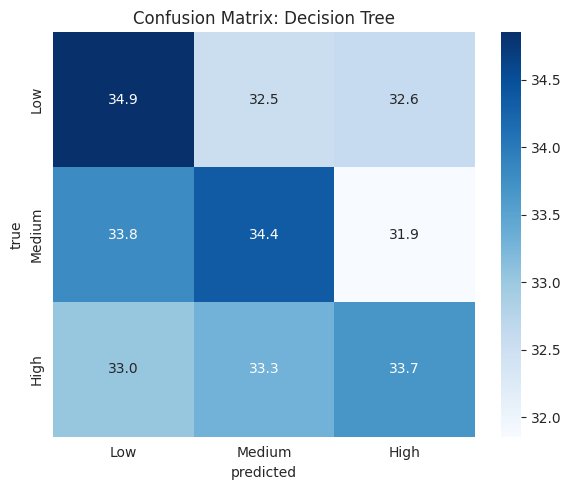

In [21]:
cm = confusion_matrix(y_test, y_pred)
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel('predicted')
ax.set_ylabel('true')
ax.set_title(f'Confusion Matrix: {best_model_name}')
plt.tight_layout()
plt.show()

As understood, it is not much more than simple guessing. The only thing is that the Medium Severity Level is slightly better found than others.

### ROC-AUC

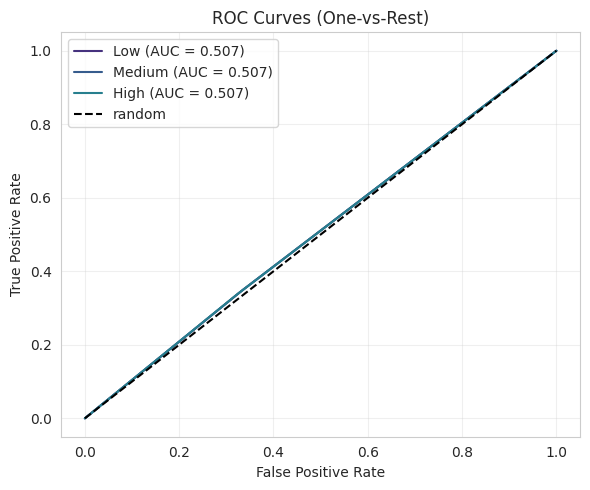

In [22]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, roc_auc_score

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

fig, ax = plt.subplots(figsize=(6, 5))
for i, cls in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    auc = roc_auc_score(y_test_bin[:, i], y_pred_proba[:, i])
    ax.plot(fpr, tpr, label=f'{cls} (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', label='random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves (One-vs-Rest)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

As this figure shows, the model actually doesn't learn anything - just guessing.